## **Imports**

In [ ]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms


## **Setup**

In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BATCH_SIZE     = 128
NUM_EPOCHS     = 30
LEARNING_RATE  = 1e-3
LAMBDA_LIST    = [1e-5, 1e-4, 1e-3]   # low / medium / high sparsity pressure
GATE_THRESHOLD = 1e-2                  # gates below this are counted as pruned


Using device: cuda


## **Dataset & Dataloaders (CIFAR-10)**

---



We apply standard CIFAR-10 normalization and use random crop + horizontal flip augmentation during training to improve generalisation.

In [5]:
import torchvision
import torchvision.transforms as transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True,  download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2
)
testloader = torch.utils.data.DataLoader(
    testset,  batch_size=256,        shuffle=False, num_workers=2
)

print(f"Train samples: {len(trainset):,}   Test samples: {len(testset):,}")


100%|██████████| 170M/170M [00:07<00:00, 21.4MB/s]


Train samples: 50,000   Test samples: 10,000



## **PrunableLinear Layer**

Each weight has an associated learnable `gate_score`.  During the forward pass:

```
gates         = sigmoid(gate_scores)          # squash to (0, 1)
pruned_weight = weight * gates                # element-wise mask
output        = F.linear(x, pruned_weight, bias)
```

Key design decisions:
- **Kaiming uniform init** for `weight` — same as `nn.Linear`, keeps activations well-scaled at init.
- **gate_scores initialised to 0** — `sigmoid(0) = 0.5`, so all gates start at 50 % open.  This is a neutral starting point: the network hasn't committed to pruning or keeping anything yet.
- Gradients flow through both `weight` and `gate_scores` automatically via autograd.


In [7]:
import torch.nn as nn
class PrunableLinear(nn.Module):
    """
    Drop-in replacement for nn.Linear that learns to prune its own weights.

    Each weight w_ij is multiplied by sigmoid(g_ij) where g_ij is a
    learnable scalar (gate_score).  An L1 penalty on the gate values
    during training drives weak gates toward 0, effectively removing
    the corresponding weight from the network.
    """

    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        # ── Learnable parameters ──────────────────────────────────────────
        self.weight      = nn.Parameter(torch.empty(out_features, in_features))
        self.gate_scores = nn.Parameter(torch.empty(out_features, in_features))

        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter("bias", None)

        self._reset_parameters()

    def _reset_parameters(self):
        # Kaiming uniform — matches the default nn.Linear initialisation
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

        # Gate scores start at 0  →  sigmoid(0) = 0.5
        # Neutral: neither pushing toward pruning nor keeping
        nn.init.constant_(self.gate_scores, 0.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates         = torch.sigmoid(self.gate_scores)   # (0, 1)
        pruned_weight = self.weight * gates               # element-wise mask
        return F.linear(x, pruned_weight, self.bias)

    def gate_values(self) -> torch.Tensor:
        """Return the current gate values (detached) for inspection."""
        return torch.sigmoid(self.gate_scores).detach()


## **PrunableMLP**

A 3-layer fully-connected network built entirely from `PrunableLinear` layers.  CIFAR-10 images (3 × 32 × 32 = 3072 features) are flattened before being fed in.

In [8]:
class PrunableMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32 * 32 * 3, 1024)
        self.fc2 = PrunableLinear(1024, 512)
        self.fc3 = PrunableLinear(512, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)   # flatten: (B, 3, 32, 32) → (B, 3072)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)           # raw logits; loss fn applies softmax internally


## **Main Functions**

In [9]:
def compute_sparsity(model: nn.Module, threshold: float = GATE_THRESHOLD):
    """
    Returns (sparsity_pct, flat_gate_array).
    sparsity_pct = percentage of gates with value < threshold.
    """
    all_gates = []
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            g = module.gate_values().cpu().view(-1)
            all_gates.append(g)

    if not all_gates:
        return 0.0, None

    all_gates  = torch.cat(all_gates)
    num_total  = all_gates.numel()
    num_pruned = (all_gates < threshold).sum().item()
    sparsity   = 100.0 * num_pruned / num_total
    return sparsity, all_gates.numpy()


def evaluate_accuracy(model: nn.Module, dataloader) -> float:
    """Compute top-1 accuracy on the given dataloader."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            _, preds = model(images).max(1)
            total   += labels.size(0)
            correct += (preds == labels).sum().item()
    return 100.0 * correct / total


## **Training Function**

**Loss:**  `Total = CrossEntropy + λ × Σ sigmoid(gate_scores)`

- `CrossEntropy` drives the network to classify correctly.
- `λ × Σ gates` is the **L1 sparsity penalty** — it exerts a constant downward pressure on every gate value, regardless of how small it already is.  This is the key property that drives gates all the way to **exactly zero** rather than just making them small (unlike an L2 / squared penalty).
- `λ` (lambda) controls the trade-off: larger λ → more pruning, potentially lower accuracy.

We use `gates.sum()` (raw sum across all layers) rather than a normalised mean so that the penalty scales with the total number of active connections, which is the quantity we actually want to minimise.


In [10]:
def train_one_model(lambda_coef: float):
    """
    Train a fresh PrunableMLP with the given sparsity coefficient.
    Returns (state_dict, test_accuracy, sparsity_pct, all_gate_values).
    """
    model     = PrunableMLP().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    print(f"\n{'='*60}")
    print(f"  Training with λ = {lambda_coef}")
    print(f"{'='*60}")

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        running_total = 0.0
        running_cls   = 0.0
        running_sp    = 0.0
        t0 = time.time()

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            logits   = model(images)
            cls_loss = criterion(logits, labels)

            # ── Sparsity penalty: L1 norm of all gate values ──────────────
            sparsity_loss = sum(
                torch.sigmoid(m.gate_scores).sum()
                for m in model.modules()
                if isinstance(m, PrunableLinear)
            )

            loss = cls_loss + lambda_coef * sparsity_loss
            loss.backward()
            optimizer.step()

            n = images.size(0)
            running_total += loss.item()          * n
            running_cls   += cls_loss.item()      * n
            running_sp    += sparsity_loss.item() * n

        N = len(trainloader.dataset)
        sparsity, _ = compute_sparsity(model)

        print(
            f"  Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"loss={running_total/N:.4f} "
            f"(cls={running_cls/N:.4f}, sp={running_sp/N:.4f}) | "
            f"sparsity={sparsity:.1f}% | "
            f"time={time.time()-t0:.1f}s"
        )

    test_acc        = evaluate_accuracy(model, testloader)
    sparsity, gates = compute_sparsity(model)
    print(f"\n  ✓  λ={lambda_coef}  →  acc={test_acc:.2f}%,  sparsity={sparsity:.2f}%")

    return model.state_dict(), test_acc, sparsity, gates


## Run Experiments

Train one model per λ value and collect results.

In [14]:
import math
import time
import torch.nn.functional as F
results  = []
best_idx = None

for lam in LAMBDA_LIST:
    state_dict, acc, sparsity, gates = train_one_model(lam)
    results.append({
        "lambda":     lam,
        "acc":        acc,
        "sparsity":   sparsity,
        "state_dict": state_dict,
        "gates":      gates,
    })

    # Track best model by accuracy (tie-break: higher sparsity preferred)
    if best_idx is None or acc > results[best_idx]["acc"]:
        best_idx = len(results) - 1



  Training with λ = 1e-05
  Epoch 01/30 | loss=18.5388 (cls=1.7835, sp=1675529.9970) | sparsity=0.0% | time=21.3s
  Epoch 02/30 | loss=15.3766 (cls=1.5943, sp=1378227.5220) | sparsity=0.0% | time=19.6s
  Epoch 03/30 | loss=12.8212 (cls=1.5107, sp=1131050.6451) | sparsity=0.0% | time=20.5s
  Epoch 04/30 | loss=10.8022 (cls=1.4516, sp=935057.0091) | sparsity=0.0% | time=19.5s
  Epoch 05/30 | loss=9.2358 (cls=1.4076, sp=782819.0793) | sparsity=0.0% | time=20.6s
  Epoch 06/30 | loss=8.0202 (cls=1.3722, sp=664798.8392) | sparsity=0.0% | time=19.3s
  Epoch 07/30 | loss=7.0673 (cls=1.3402, sp=572700.5445) | sparsity=0.0% | time=20.6s
  Epoch 08/30 | loss=6.3180 (cls=1.3186, sp=499934.2702) | sparsity=0.0% | time=19.6s
  Epoch 09/30 | loss=5.7059 (cls=1.2897, sp=441614.9758) | sparsity=0.0% | time=20.1s
  Epoch 10/30 | loss=5.2095 (cls=1.2670, sp=394247.7781) | sparsity=0.0% | time=19.9s
  Epoch 11/30 | loss=4.8029 (cls=1.2504, sp=355243.7669) | sparsity=0.0% | time=19.7s
  Epoch 12/30 | loss

## Summary Table

In [17]:
print("\n=== Results Summary ===")
print(f"{'Lambda':<12} {'Test Accuracy (%)':>18} {'Sparsity (%)':>14}")
print("-" * 46)
for r in results:
    marker = " ← best" if r["lambda"] == results[best_idx]["lambda"] else ""
    print(f"{r['lambda']:<12} {r['acc']:>18.2f} {r['sparsity']:>14.2f}{marker}")

best = results[best_idx]
print(f"\nBest model: λ={best['lambda']}, acc={best['acc']:.2f}%, sparsity={best['sparsity']:.2f}%")



=== Results Summary ===
Lambda        Test Accuracy (%)   Sparsity (%)
----------------------------------------------
1e-05                     58.55          51.07
0.0001                    59.00          91.82 ← best
0.001                     51.45          99.81

Best model: λ=0.0001, acc=59.00%, sparsity=91.82%


## Gate Value Distribution

A successful self-pruning run produces a **bimodal distribution**:
- A large spike near **0** — gates the network has decided to close (pruned weights)
- A cluster spread across **0.3–1.0** — gates kept open for important connections

The gap between the two clusters shows the network has learned a meaningful binary distinction, not just uniform shrinkage.


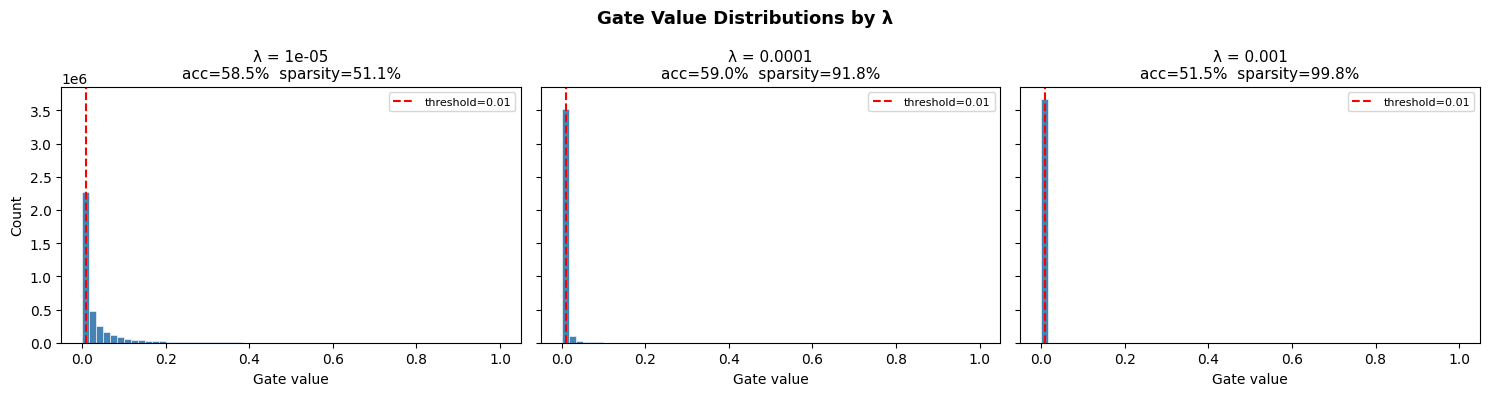

Saved → gate_distributions.png


In [19]:
import matplotlib.pyplot as plt
best       = results[best_idx]
gates_np   = best["gates"]

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4), sharey=True)
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    ax.hist(r["gates"], bins=60, range=(0.0, 1.0), color="steelblue",
            edgecolor="white", linewidth=0.4)
    ax.axvline(GATE_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
               label=f"threshold={GATE_THRESHOLD}")
    ax.set_title(f"λ = {r['lambda']}\nacc={r['acc']:.1f}%  sparsity={r['sparsity']:.1f}%",
                 fontsize=11)
    ax.set_xlabel("Gate value")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Count")
fig.suptitle("Gate Value Distributions by λ", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("gate_distributions.png", dpi=150)
plt.show()
print("Saved → gate_distributions.png")
